In [ ]:
from utils import load_data

train_path = "train.csv"
val_path = "validation.csv"

train_data = load_data(train_path)
val_data = load_data(val_path)

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(2)
torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor(5)


In [9]:
import urllib.request
import ssl
import certifi

url = "https://download.pytorch.org/models/resnet18-f37072fd.pth"
ctx = ssl.create_default_context(cafile=certifi.where())

req = urllib.request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0"} 
)

with urllib.request.urlopen(req, context=ctx) as response:
    data = response.read()
    with open("resnet18-f37072fd.pth", "wb") as f:
        f.write(data)

print("Downloaded weights!")

Downloaded weights!


In [10]:
import torch.nn as nn
import torch

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, h, w = x.size()

        # Squeeze
        y = x.mean(dim=(2, 3))  # Global Avg Pool

        # Excitation
        y = torch.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))

        y = y.view(b, c, 1, 1)

        # Scale
        return x * y

In [11]:
import torchvision.models as models

class ResNet18_SE(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.backbone = models.resnet18(pretrained=False)

        # load pretrained weights
        state_dict = torch.load("resnet18-f37072fd.pth")
        self.backbone.load_state_dict(state_dict)

        # SE blocks
        self.se1 = SEBlock(64)
        self.se2 = SEBlock(128)
        self.se3 = SEBlock(256)
        self.se4 = SEBlock(512)

        # replace fc
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.se1(x)

        x = self.backbone.layer2(x)
        x = self.se2(x)

        x = self.backbone.layer3(x)
        x = self.se3(x)

        x = self.backbone.layer4(x)
        x = self.se4(x)

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x)

        return x

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # can be None or tensor of class weights

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # probability of correct class
        
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        return focal_loss.mean()

In [13]:
import torch
import torch.optim as optim
import params

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = ResNet18_SE(num_classes=10)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=params.lr)

/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [14]:
outfile = open("results.txt", 'a')
outfile.write("----------------------------\n")
outfile.write("Ablation for task 1.2\n")
outfile.write("---------------------\n")

22

In [ ]:
import time
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

gamma_results = []
gamma_values = [1,2,3]

for gamma in gamma_values:
  criterion = FocalLoss(gamma=gamma)
  outfile.write(f"Training with gamma: {gamma}\n")

  model = ResNet18_SE(num_classes=10)
  model = model.to(device)
  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

  best_auc = 0
  best_model_state = None
  

  for epoch in range(3): # shorter run to judge trends
    start = time.time()
    model.train()

    outfile.write(f"Running epoch: {epoch+1}\n")

    for images, labels in train_data:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

    model.eval()
    all_labels = []
    all_probs = []

    outfile.write(f"  Evaluations for the epoch\n")

    with torch.no_grad():
      for images, labels in val_data:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    y_true = label_binarize(all_labels, classes=list(range(10)))

    auc = roc_auc_score(y_true, all_probs, average='macro', multi_class='ovr')

    outfile.write(f"Epoch {epoch+1} done, Val AUC: {auc:.4f}\n")
    outfile.write(f"Time taken: {time.time()-start:.2f}s\n")

    if auc > best_auc:
      best_auc = auc
      best_model_state = model.state_dict()

    gamma_results.append(best_auc)

/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/adit/Documents/Acads/Vision/Assignments/A3/vevn/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Argument

In [16]:
outfile.close()

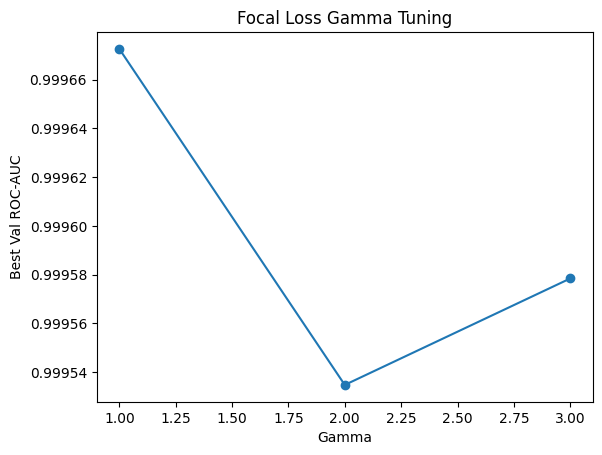

<Figure size 640x480 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt

gamma_results = gamma_results[2::3]
plt.plot(gamma_values, gamma_results, marker='o')
plt.xlabel("Gamma")
plt.ylabel("Best Val ROC-AUC")
plt.title("Focal Loss Gamma Tuning")
plt.show()
plt.savefig("Ablation_plot12")

In [ ]:
with open("results.txt", "a") as f:
    f.write("\n------------------------------\n")
    f.write("Ablation training results for 1.2\n")
    f.write("------------------------------\n")
    f.write("Values of ROC-AUC across changing gamma:\n")
    for gr in gamma_results:
        f.write(f"{gr}\n")

In [ ]:
from utils import load_data

test_path = "test.csv"

test_data = load_data(test_path)

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

model = ResNet18_SE(num_classes=10)
model.load_state_dict(best_model_state)


In [ ]:
all_preds = []
all_labels = []
all_probs = []

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

with torch.no_grad():
  for images, labels in test_data:
    images = images.to(device)
    outputs = model(images)

    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

    all_probs.append(probs.cpu().numpy())
    all_preds.append(preds.cpu().numpy())
    all_labels.append(labels.numpy())

import numpy as np
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import label_binarize

y_true = label_binarize(all_labels, classes=list(range(10)))
auc = roc_auc_score(y_true, all_probs, average='macro', multi_class='ovr')

acc = accuracy_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds, average='macro')

print("Accuracy: ", acc)
print("F1 Score: ", f1)
print("Macro ROC-AUC: ", auc)

with open("results.txt", "a") as f:
    f.write("\n------------------------------\n")
    f.write("Ablation Test results for 1.2\n")
    f.write("------------------------------\n")
    f.write(f"Accuracy: {acc}\n")
    f.write(f"F1 Score: {f1}\n")
    f.write(f"Macro ROC-AUC: {auc}\n")
